In [1]:
import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn

from datasets import load_dataset, Dataset, DatasetDict

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score
from sklearn.utils.class_weight import compute_class_weight

C:\Users\nethr\anaconda3\envs\ticket-routing\lib\site-packages\transformers\utils\generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
C:\Users\nethr\anaconda3\envs\ticket-routing\lib\site-packages\transformers\utils\generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(


In [2]:
ds = load_dataset("Tobi-Bueck/customer-support-tickets")

In [3]:
ds["train"][6]

{'subject': 'System Interruptions',
 'body': 'Dear Customer Support Team,\\n\\nI am submitting a report regarding multiple system service disruptions that are currently interfering with project operations and client interactions. These interruptions have notably reduced efficiency and caused delays in meeting important deadlines.\\n\\nInitial assessments suggest that the primary issue may be linked to widespread failures in network hardware connectivity. We have already carried out several basic troubleshooting procedures, such as rebooting devices and performing initial system checks, but the problems persist.',
 'answer': "Thank you for bringing the system disruptions to our attention. We understand the importance of maintaining stable services for project workflows and client communications, and we apologize for the inconvenience caused. To assist us in diagnosing the issue, could you please provide specific details about the affected systems or services, the approximate start time 

In [4]:
ds["train"].column_names

['subject',
 'body',
 'answer',
 'type',
 'queue',
 'priority',
 'language',
 'version',
 'tag_1',
 'tag_2',
 'tag_3',
 'tag_4',
 'tag_5',
 'tag_6',
 'tag_7',
 'tag_8']

In [5]:
type(ds)

datasets.dataset_dict.DatasetDict

In [6]:
train_ds = ds["train"]

In [7]:
train_en_ds = train_ds.filter(lambda x: x["language"] == "en")

In [8]:
df = train_en_ds.to_pandas()

In [9]:
df.head()

,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
0,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...","Thank you for reaching out, <name>. We are awa...",Incident,Technical Support,high,en,51.0,Account,Disruption,Outage,IT,Tech Support,None,None,None
1,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Thank you for your inquiry. Our products suppo...,Request,Returns and Exchanges,medium,en,51.0,Product,Feature,Tech Support,None,None,None,None,None
2,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this mes...",We appreciate you reaching out with your billi...,Request,Billing and Payments,low,en,51.0,Billing,Payment,Account,Documentation,Feedback,None,None,None
3,Question About Marketing Agency Software Compa...,"Dear Support Team,\n\nI hope this message reac...",Thank you for your inquiry. Our product suppor...,Problem,Sales and Pre-Sales,medium,en,51.0,Product,Feature,Feedback,Tech Support,None,None,None,None
4,Feature Query,"Dear Customer Support,\n\nI hope this message ...",Thank you for your inquiry. Please specify whi...,Request,Technical Support,high,en,51.0,Feature,Product,Documentation,Feedback,None,None,None,None


In [10]:
df.shape

(28261, 16)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28261 entries, 0 to 28260
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   subject   24622 non-null  object 
 1   body      28260 non-null  object 
 2   answer    28255 non-null  object 
 3   type      28261 non-null  object 
 4   queue     28261 non-null  object 
 5   priority  28261 non-null  object 
 6   language  28261 non-null  object 
 7   version   16338 non-null  float64
 8   tag_1     28261 non-null  object 
 9   tag_2     28245 non-null  object 
 10  tag_3     28148 non-null  object 
 11  tag_4     25677 non-null  object 
 12  tag_5     16301 non-null  object 
 13  tag_6     7908 non-null   object 
 14  tag_7     3699 non-null   object 
 15  tag_8     1608 non-null   object 
dtypes: float64(1), object(15)
memory usage: 3.4+ MB


In [12]:
df["text"] = (
    df["subject"].fillna("") + " " + df["body"].fillna("")
)

In [13]:
df[["subject", "body", "text"]].head(3)

,subject,body,text
0,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...","Account Disruption Dear Customer Support Team,..."
1,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Query About Smart Home System Integration Feat...
2,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this mes...",Inquiry Regarding Invoice Details Dear Custome...


In [14]:
df["language"].value_counts()

language
en    28261
Name: count, dtype: int64

In [15]:
df = df[["text", "queue", "priority"]]
df.head()

,text,queue,priority
0,"Account Disruption Dear Customer Support Team,...",Technical Support,high
1,Query About Smart Home System Integration Feat...,Returns and Exchanges,medium
2,Inquiry Regarding Invoice Details Dear Custome...,Billing and Payments,low
3,Question About Marketing Agency Software Compa...,Sales and Pre-Sales,medium
4,"Feature Query Dear Customer Support,\n\nI hope...",Technical Support,high


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

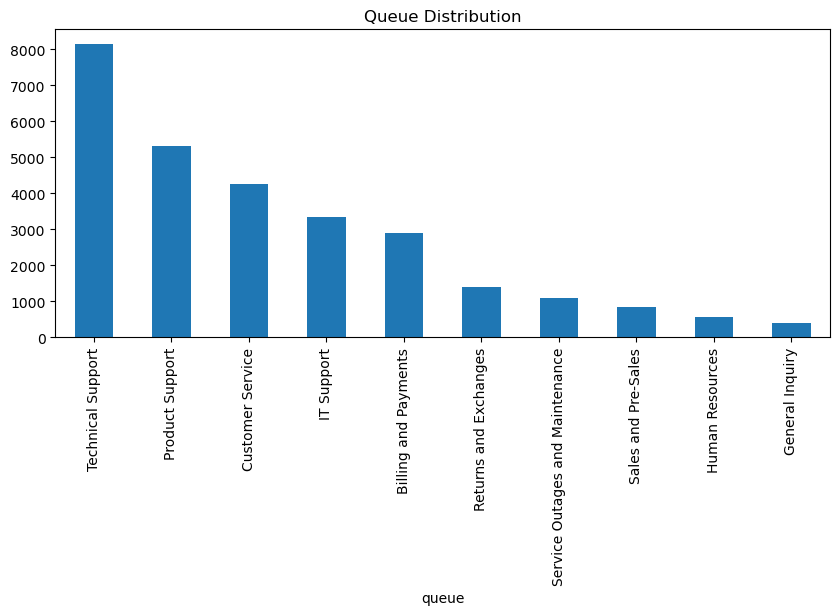

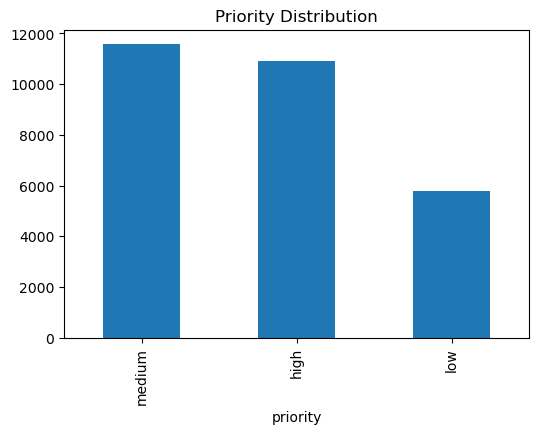

In [17]:
plt.figure(figsize=(10,4))
df["queue"].value_counts().plot(kind="bar")
plt.title("Queue Distribution")
plt.show()

plt.figure(figsize=(6,4))
df["priority"].value_counts().plot(kind="bar")
plt.title("Priority Distribution")
plt.show()

In [18]:
df["text_len"] = df["text"].str.split().str.len()

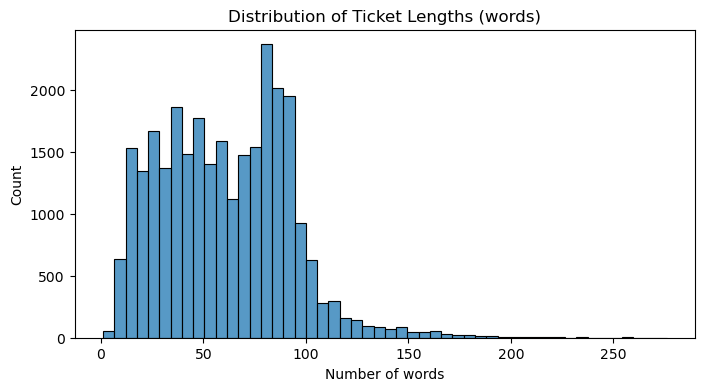

In [19]:
plt.figure(figsize=(8,4))
sns.histplot(df["text_len"], bins=50)
plt.title("Distribution of Ticket Lengths (words)")
plt.xlabel("Number of words")
plt.show()

In [20]:
df.isnull().sum().sort_values(ascending=False)

text        0
queue       0
priority    0
text_len    0
dtype: int64

In [21]:
(df["text"].str.strip() == "").sum()

np.int64(0)

In [22]:
df["queue"].unique()

array(['Technical Support', 'Returns and Exchanges',
       'Billing and Payments', 'Sales and Pre-Sales',
       'Service Outages and Maintenance', 'Product Support', 'IT Support',
       'Customer Service', 'Human Resources', 'General Inquiry'],
      dtype=object)

In [23]:
df["priority"].unique()

array(['high', 'medium', 'low'], dtype=object)

In [24]:
label_summary = pd.DataFrame({
    "queue_count": df["queue"].value_counts(),
    "priority_count": df["priority"].value_counts()
})

In [25]:
label_summary

,queue_count,priority_count
Billing and Payments,2897.0,NaN
Customer Service,4269.0,NaN
General Inquiry,404.0,NaN
Human Resources,553.0,NaN
IT Support,3333.0,NaN
Product Support,5305.0,NaN
Returns and Exchanges,1402.0,NaN
Sales and Pre-Sales,843.0,NaN
Service Outages and Maintenance,1106.0,NaN
Technical Support,8149.0,NaN


In [26]:
from sklearn.preprocessing import LabelEncoder

queue_encoder = LabelEncoder()
priority_encoder = LabelEncoder()

df["queue_id"] = queue_encoder.fit_transform(df["queue"])
df["priority_id"] = priority_encoder.fit_transform(df["priority"])

df.head()

,text,queue,priority,text_len,queue_id,priority_id
0,"Account Disruption Dear Customer Support Team,...",Technical Support,high,84,9,0
1,Query About Smart Home System Integration Feat...,Returns and Exchanges,medium,83,6,2
2,Inquiry Regarding Invoice Details Dear Custome...,Billing and Payments,low,95,0,1
3,Question About Marketing Agency Software Compa...,Sales and Pre-Sales,medium,103,7,2
4,"Feature Query Dear Customer Support,\n\nI hope...",Technical Support,high,99,9,0


In [27]:
from datasets import Dataset

hf_dataset = Dataset.from_pandas(df[["text", "queue_id", "priority_id"]])

dataset = hf_dataset.train_test_split(test_size=0.3, seed=42)

temp_split = dataset["test"].train_test_split(test_size=0.5, seed=42)

dataset = {
    "train": dataset["train"],
    "validation": temp_split["train"],
    "test": temp_split["test"]
}

dataset

{'train': Dataset({
     features: ['text', 'queue_id', 'priority_id'],
     num_rows: 19782
 }),
 'validation': Dataset({
     features: ['text', 'queue_id', 'priority_id'],
     num_rows: 4239
 }),
 'test': Dataset({
     features: ['text', 'queue_id', 'priority_id'],
     num_rows: 4240
 })}

In [28]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

def tokenize(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

for split in dataset:
    dataset[split] = dataset[split].map(tokenize, batched=True)

for split in dataset:
    dataset[split].set_format(
        type="torch",
        columns=["input_ids", "attention_mask", "queue_id", "priority_id"]
    )

C:\Users\nethr\anaconda3\envs\ticket-routing\lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Map:   0%|          | 0/19782 [00:00<?, ? examples/s]

Map:   0%|          | 0/4239 [00:00<?, ? examples/s]

Map:   0%|          | 0/4240 [00:00<?, ? examples/s]

In [29]:
from datasets import DatasetDict

queue_dataset = DatasetDict({
    "train": dataset["train"].rename_column("queue_id", "labels"),
    "validation": dataset["validation"].rename_column("queue_id", "labels"),
    "test": dataset["test"].rename_column("queue_id", "labels")
}).remove_columns(["priority_id"])

priority_dataset = DatasetDict({
    "train": dataset["train"].rename_column("priority_id", "labels"),
    "validation": dataset["validation"].rename_column("priority_id", "labels"),
    "test": dataset["test"].rename_column("priority_id", "labels")
}).remove_columns(["queue_id"])

In [30]:
from sklearn.metrics import accuracy_score, f1_score
import numpy as np

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    return {
        "accuracy": accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average="macro"),
        "weighted_f1": f1_score(labels, preds, average="weighted")
    }

In [31]:
queue_model_v1 = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=len(queue_encoder.classes_)
)

priority_model_v1 = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=len(priority_encoder.classes_)
)

training_args_v1 = TrainingArguments(
    output_dir="./baseline",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1"
)

queue_trainer_v1 = Trainer(
    model=queue_model_v1,
    args=training_args_v1,
    train_dataset=queue_dataset["train"],
    eval_dataset=queue_dataset["validation"],
    compute_metrics=compute_metrics,
    tokenizer=tokenizer
)

priority_trainer_v1 = Trainer(
    model=priority_model_v1,
    args=training_args_v1,
    train_dataset=priority_dataset["train"],
    eval_dataset=priority_dataset["validation"],
    compute_metrics=compute_metrics,
    tokenizer=tokenizer
)

queue_trainer_v1.train()
priority_trainer_v1.train()

metrics_queue_v1 = queue_trainer_v1.evaluate(queue_dataset["test"])
metrics_priority_v1 = priority_trainer_v1.evaluate(priority_dataset["test"])

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['pre_classifier.bias', 'classifier.weight', 'classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['pre_classifier.bias', 'classifier.weight', 'classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
You're using a DistilBertTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,1.641200,1.576016,0.428639,0.318632,0.401367
2,1.423600,1.378576,0.514036,0.418924,0.497887
3,1.081700,1.310083,0.559094,0.470962,0.549699


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,1.001900,0.968753,0.509082,0.431939,0.481447
2,0.898900,0.895007,0.588110,0.557066,0.580384
3,0.622700,0.876529,0.635527,0.610299,0.630154


Checkpoint destination directory ./baseline\checkpoint-1237 already exists and is non-empty.Saving will proceed but saved results may be invalid.
Checkpoint destination directory ./baseline\checkpoint-2474 already exists and is non-empty.Saving will proceed but saved results may be invalid.
Checkpoint destination directory ./baseline\checkpoint-3711 already exists and is non-empty.Saving will proceed but saved results may be invalid.


In [32]:
from sklearn.utils.class_weight import compute_class_weight
import torch

queue_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(df["queue_id"]),
    y=df["queue_id"]
)

priority_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(df["priority_id"]),
    y=df["priority_id"]
)

queue_weights = torch.tensor(queue_weights, dtype=torch.float)
priority_weights = torch.tensor(priority_weights, dtype=torch.float)

In [33]:
import torch.nn as nn
from transformers import Trainer

class WeightedTrainer(Trainer):
    def __init__(self, class_weights=None, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        loss_fct = nn.CrossEntropyLoss(
            weight=self.class_weights.to(model.device)
        )

        loss = loss_fct(logits, labels)
        return (loss, outputs) if return_outputs else loss

In [34]:
queue_model_v2 = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=len(queue_encoder.classes_)
)

priority_model_v2 = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=len(priority_encoder.classes_)
)

training_args_v2 = TrainingArguments(
    output_dir="./weighted",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1"
)

queue_trainer_v2 = WeightedTrainer(
    model=queue_model_v2,
    args=training_args_v2,
    train_dataset=queue_dataset["train"],
    eval_dataset=queue_dataset["validation"],
    compute_metrics=compute_metrics,
    tokenizer=tokenizer,
    class_weights=queue_weights
)

priority_trainer_v2 = WeightedTrainer(
    model=priority_model_v2,
    args=training_args_v2,
    train_dataset=priority_dataset["train"],
    eval_dataset=priority_dataset["validation"],
    compute_metrics=compute_metrics,
    tokenizer=tokenizer,
    class_weights=priority_weights
)

queue_trainer_v2.train()
priority_trainer_v2.train()

metrics_queue_v2_before = queue_trainer_v2.evaluate(queue_dataset["test"])
metrics_priority_v2_before = priority_trainer_v2.evaluate(priority_dataset["test"])

C:\Users\nethr\anaconda3\envs\ticket-routing\lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['pre_classifier.bias', 'classifier.weight', 'classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['pre_classifier.bias', 'classifier.weight', 'classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,1.886100,1.749956,0.295589,0.296171,0.294881
2,1.562100,1.511407,0.396084,0.397225,0.391211
3,1.130100,1.428511,0.454824,0.482529,0.450655


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,1.053400,1.021728,0.460722,0.444033,0.454633
2,0.949600,0.953961,0.543524,0.528836,0.541098
3,0.730500,0.940519,0.586695,0.577949,0.587043


Checkpoint destination directory ./weighted\checkpoint-1237 already exists and is non-empty.Saving will proceed but saved results may be invalid.
Checkpoint destination directory ./weighted\checkpoint-2474 already exists and is non-empty.Saving will proceed but saved results may be invalid.
Checkpoint destination directory ./weighted\checkpoint-3711 already exists and is non-empty.Saving will proceed but saved results may be invalid.


In [45]:
def extract_metrics(name, metrics):
    return {
        "Model": name,
        "Accuracy": metrics["eval_accuracy"],
        "Macro_F1": metrics["eval_macro_f1"],
        "Weighted_F1": metrics["eval_weighted_f1"]
    }

comparison_queue = pd.DataFrame([
    extract_metrics("Queue_v1", metrics_queue_v1),
    extract_metrics("Queue_v2_Weighted", metrics_queue_v2_before)
])

comparison_priority = pd.DataFrame([
    extract_metrics("Priority_v1", metrics_priority_v1),
    extract_metrics("Priority_v2_Weighted", metrics_priority_v2_before)
])

comparison_priority

,Model,Accuracy,Macro_F1,Weighted_F1
0,Priority_v1,0.629717,0.602941,0.624402
1,Priority_v2_Weighted,0.583019,0.575208,0.583477


In [44]:
comparison_queue

,Model,Accuracy,Macro_F1,Weighted_F1
0,Queue_v1,0.572406,0.485405,0.562479
1,Queue_v2_Weighted,0.471462,0.484234,0.466631


In [46]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
queue_model_v1.to(device)
priority_model_v1.to(device)

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): MultiHeadSelfAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)
 

In [47]:
def predict_queue(text):
    queue_model_v1.eval()
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=128)
    inputs = {k: v.to(queue_model_v1.device) for k, v in inputs.items()}
    with torch.no_grad():
        outputs = queue_model_v1(**inputs)
        probs = torch.softmax(outputs.logits, dim=1)
        pred_id = probs.argmax(dim=1).item()
    return queue_encoder.inverse_transform([pred_id])[0], probs.max().item()

def predict_priority(text):
    priority_model_v1.eval()
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=128)
    inputs = {k: v.to(priority_model_v1.device) for k, v in inputs.items()}
    with torch.no_grad():
        outputs = priority_model_v1(**inputs)
        probs = torch.softmax(outputs.logits, dim=1)
        pred_id = probs.argmax(dim=1).item()
    return priority_encoder.inverse_transform([pred_id])[0], probs.max().item()

In [48]:
queue_feedback_memory = []
priority_feedback_memory = []

In [49]:
def active_learning_step(text, threshold=0.85):

    print("\n" + "="*70)
    print("TICKET:\n", text)
    print("="*70)

    q_label, q_conf = predict_queue(text)
    print("\nQueue:", q_label, "| Confidence:", round(q_conf,3))

    if q_conf < threshold:
        for i, label in enumerate(queue_encoder.classes_):
            print(f"{i} → {label}")
        selected = int(input("Correct queue label number: "))
        queue_feedback_memory.append({
            "text": text,
            "queue_id": queue_encoder.transform([queue_encoder.classes_[selected]])[0]
        })

    p_label, p_conf = predict_priority(text)
    print("\nPriority:", p_label, "| Confidence:", round(p_conf,3))

    if p_conf < threshold:
        for i, label in enumerate(priority_encoder.classes_):
            print(f"{i} → {label}")
        selected = int(input("Correct priority label number: "))
        priority_feedback_memory.append({
            "text": text,
            "priority_id": priority_encoder.transform([priority_encoder.classes_[selected]])[0]
        })

In [56]:
from datasets import concatenate_datasets

In [59]:
def retrain_queue_from_feedback():
    global queue_dataset, queue_trainer_v1

    if len(queue_feedback_memory) == 0:
        print("No queue feedback.")
        return

    print("Preparing queue feedback dataset...")

    feedback_df = pd.DataFrame(queue_feedback_memory)
    feedback_dataset = Dataset.from_pandas(feedback_df)

    feedback_dataset = feedback_dataset.map(tokenize, batched=True)
    feedback_dataset.set_format(
        type="torch",
        columns=["input_ids", "attention_mask", "queue_id"]
    )
    original_train = queue_dataset["train"].rename_column("labels", "queue_id")
    combined = concatenate_datasets([original_train, feedback_dataset])
    combined = combined.rename_column("queue_id", "labels")

    queue_dataset["train"] = combined
    queue_trainer_v1.train_dataset = queue_dataset["train"]

    print("Retraining queue model on updated dataset...")
    queue_trainer_v1.train()

    queue_feedback_memory.clear()
    print("Queue model updated permanently.")

In [60]:
def retrain_priority_from_feedback():
    global priority_dataset, priority_trainer_v1

    if len(priority_feedback_memory) == 0:
        print("No priority feedback.")
        return

    print("Preparing priority feedback dataset...")

    feedback_df = pd.DataFrame(priority_feedback_memory)
    feedback_dataset = Dataset.from_pandas(feedback_df)

    feedback_dataset = feedback_dataset.map(tokenize, batched=True)
    feedback_dataset.set_format(
        type="torch",
        columns=["input_ids", "attention_mask", "priority_id"]
    )

    original_train = priority_dataset["train"].rename_column("labels", "priority_id")

    combined = concatenate_datasets([original_train, feedback_dataset])
    combined = combined.rename_column("priority_id", "labels")
    priority_dataset["train"] = combined

    priority_trainer_v1.train_dataset = priority_dataset["train"]

    print("Retraining priority model on updated dataset...")
    priority_trainer_v1.train()

    priority_feedback_memory.clear()
    print("Priority model updated permanently.")

In [52]:
ticket_texts = [
"Dear Customer Support Team,\n\nI am writing to report that my most recent billing statement shows two identical charges for the same subscription renewal period. I have verified my payment history and can confirm that I only authorized a single renewal transaction.\n\nCould you please investigate this issue and provide clarification regarding the duplicate charge? I would also appreciate information on when I can expect the excess amount to be refunded.",

"Dear Customer Support Team,\n\nI am currently experiencing repeated system crashes whenever I attempt to upload required documentation through the mobile application. The application closes unexpectedly without displaying any error notification.\n\nI have already reinstalled the app and restarted my device multiple times, but the issue continues to persist. This problem is affecting my workflow and requires urgent technical assistance.",

"Dear Customer Support Team,\n\nFollowing a recent password reset request, I am no longer able to log into my account. The system consistently displays an 'invalid credentials' message, even though I am entering the updated password correctly.\n\nKindly advise on how this access issue can be resolved at the earliest convenience, as I require immediate access to my account settings.",

"Dear Customer Support Team,\n\nI am submitting a complaint regarding an order that has been marked as delivered in the tracking system. However, I have not received the package at my registered shipping address.\n\nPlease investigate this discrepancy and inform me of the appropriate next steps, including whether a replacement shipment or refund will be issued.",

"Dear Customer Support Team,\n\nI would like to suggest the introduction of a dark mode feature within the platform interface. The current design, particularly during extended evening usage, places considerable strain on the eyes.\n\nCould you please confirm whether this feature is under consideration for an upcoming update?",

"Dear Customer Support Team,\n\nI am seeking clarification regarding the features and benefits included in the premium subscription plan. The current documentation does not clearly outline the distinctions between the standard and premium tiers.\n\nKindly provide a detailed breakdown of the premium plan offerings so that I may evaluate whether an upgrade would be suitable for my requirements.",

"Dear Customer Support Team,\n\nMy payment attempt for this month’s subscription renewal failed, and as a result, my service access has been temporarily suspended. I have already verified that sufficient funds are available in my account.\n\nPlease investigate the cause of the payment failure and restore service access as soon as possible."
]

In [53]:
for text in ticket_texts:
    active_learning_step(text, threshold=0.85)


TICKET:
 Dear Customer Support Team,

I am writing to report that my most recent billing statement shows two identical charges for the same subscription renewal period. I have verified my payment history and can confirm that I only authorized a single renewal transaction.

Could you please investigate this issue and provide clarification regarding the duplicate charge? I would also appreciate information on when I can expect the excess amount to be refunded.

Queue: Billing and Payments | Confidence: 0.997

Priority: medium | Confidence: 0.798
0 → high
1 → low
2 → medium


Correct priority label number:  2



TICKET:
 Dear Customer Support Team,

I am currently experiencing repeated system crashes whenever I attempt to upload required documentation through the mobile application. The application closes unexpectedly without displaying any error notification.

I have already reinstalled the app and restarted my device multiple times, but the issue continues to persist. This problem is affecting my workflow and requires urgent technical assistance.

Queue: Technical Support | Confidence: 0.705
0 → Billing and Payments
1 → Customer Service
2 → General Inquiry
3 → Human Resources
4 → IT Support
5 → Product Support
6 → Returns and Exchanges
7 → Sales and Pre-Sales
8 → Service Outages and Maintenance
9 → Technical Support


Correct queue label number:  9



Priority: high | Confidence: 0.951

TICKET:
 Dear Customer Support Team,

Following a recent password reset request, I am no longer able to log into my account. The system consistently displays an 'invalid credentials' message, even though I am entering the updated password correctly.

Kindly advise on how this access issue can be resolved at the earliest convenience, as I require immediate access to my account settings.

Queue: IT Support | Confidence: 0.368
0 → Billing and Payments
1 → Customer Service
2 → General Inquiry
3 → Human Resources
4 → IT Support
5 → Product Support
6 → Returns and Exchanges
7 → Sales and Pre-Sales
8 → Service Outages and Maintenance
9 → Technical Support


...


Priority: low | Confidence: 0.895

TICKET:
 Dear Customer Support Team,

I am seeking clarification regarding the features and benefits included in the premium subscription plan. The current documentation does not clearly outline the distinctions between the standard and premium tiers.

Kindly provide a detailed breakdown of the premium plan offerings so that I may evaluate whether an upgrade would be suitable for my requirements.

Queue: Returns and Exchanges | Confidence: 0.728
0 → Billing and Payments
1 → Customer Service
2 → General Inquiry
3 → Human Resources
4 → IT Support
5 → Product Support
6 → Returns and Exchanges
7 → Sales and Pre-Sales
8 → Service Outages and Maintenance
9 → Technical Support


Correct queue label number:  7



Priority: medium | Confidence: 0.669
0 → high
1 → low
2 → medium


Correct priority label number:  2



TICKET:
 Dear Customer Support Team,

My payment attempt for this month’s subscription renewal failed, and as a result, my service access has been temporarily suspended. I have already verified that sufficient funds are available in my account.

Please investigate the cause of the payment failure and restore service access as soon as possible.

Queue: Billing and Payments | Confidence: 0.995

Priority: high | Confidence: 0.916


In [54]:
print("Evaluating BEFORE active learning retrain...\n")

metrics_queue_v1_before = queue_trainer_v1.evaluate(queue_dataset["test"])
metrics_priority_v1_before = priority_trainer_v1.evaluate(priority_dataset["test"])

metrics_queue_v1_before, metrics_priority_v1_before

Evaluating BEFORE active learning retrain...



({'eval_loss': 1.2776570320129395,
  'eval_accuracy': 0.5724056603773585,
  'eval_macro_f1': 0.48540532612256315,
  'eval_weighted_f1': 0.5624785998205386,
  'eval_runtime': 9.5719,
  'eval_samples_per_second': 442.962,
  'eval_steps_per_second': 27.685,
  'epoch': 3.0},
 {'eval_loss': 0.9026499390602112,
  'eval_accuracy': 0.6297169811320755,
  'eval_macro_f1': 0.6029407383970692,
  'eval_weighted_f1': 0.6244020538365523,
  'eval_runtime': 9.7643,
  'eval_samples_per_second': 434.233,
  'eval_steps_per_second': 27.14,
  'epoch': 3.0})

In [61]:
print("Retraining models with human feedback...\n")

retrain_queue_from_feedback()
retrain_priority_from_feedback()

Retraining models with human feedback...

Preparing queue feedback dataset...


Map:   0%|          | 0/4 [00:00<?, ? examples/s]

Retraining queue model on updated dataset...


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,1.108300,1.249478,0.579618,0.506469,0.565191
2,0.750600,1.189941,0.640953,0.605412,0.637483
3,0.406500,1.220415,0.675867,0.633622,0.672656


Checkpoint destination directory ./baseline\checkpoint-1237 already exists and is non-empty.Saving will proceed but saved results may be invalid.
Checkpoint destination directory ./baseline\checkpoint-2474 already exists and is non-empty.Saving will proceed but saved results may be invalid.
Checkpoint destination directory ./baseline\checkpoint-3711 already exists and is non-empty.Saving will proceed but saved results may be invalid.


...

Map:   0%|          | 0/3 [00:00<?, ? examples/s]

Retraining priority model on updated dataset...


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,0.671200,0.837293,0.649446,0.629929,0.646997
2,0.454000,0.845041,0.699693,0.689794,0.699723
3,0.247300,0.998305,0.719038,0.708182,0.717903


Checkpoint destination directory ./baseline\checkpoint-1237 already exists and is non-empty.Saving will proceed but saved results may be invalid.
Checkpoint destination directory ./baseline\checkpoint-2474 already exists and is non-empty.Saving will proceed but saved results may be invalid.
Checkpoint destination directory ./baseline\checkpoint-3711 already exists and is non-empty.Saving will proceed but saved results may be invalid.


Priority model updated permanently.


In [62]:
print("Evaluating AFTER active learning retrain...\n")

metrics_queue_v1_after = queue_trainer_v1.evaluate(queue_dataset["test"])
metrics_priority_v1_after = priority_trainer_v1.evaluate(priority_dataset["test"])

metrics_queue_v1_after, metrics_priority_v1_after

Evaluating AFTER active learning retrain...



({'eval_loss': 1.1491395235061646,
  'eval_accuracy': 0.6938679245283019,
  'eval_macro_f1': 0.6583255444911092,
  'eval_weighted_f1': 0.6915859890599434,
  'eval_runtime': 9.6332,
  'eval_samples_per_second': 440.147,
  'eval_steps_per_second': 27.509,
  'epoch': 3.0},
 {'eval_loss': 0.9968810081481934,
  'eval_accuracy': 0.7240566037735849,
  'eval_macro_f1': 0.7107939602205405,
  'eval_weighted_f1': 0.7226040724559925,
  'eval_runtime': 9.6903,
  'eval_samples_per_second': 437.552,
  'eval_steps_per_second': 27.347,
  'epoch': 3.0})

In [63]:
final_comparison_queue = pd.DataFrame([
    extract_metrics("Queue_v1", metrics_queue_v1),
    extract_metrics("Queue_v1_After_AL", metrics_queue_v1_after)
])

final_comparison_priority = pd.DataFrame([
    extract_metrics("Priority_v1", metrics_priority_v1),
    extract_metrics("Priority_v1_After_AL", metrics_priority_v1_after)
])

print("QUEUE COMPARISON")
display(final_comparison_queue)

print("PRIORITY COMPARISON")
display(final_comparison_priority)

QUEUE COMPARISON


,Model,Accuracy,Macro_F1,Weighted_F1
0,Queue_v1,0.572406,0.485405,0.562479
1,Queue_v1_After_AL,0.693868,0.658326,0.691586


PRIORITY COMPARISON


,Model,Accuracy,Macro_F1,Weighted_F1
0,Priority_v1,0.629717,0.602941,0.624402
1,Priority_v1_After_AL,0.724057,0.710794,0.722604


In [64]:
os.makedirs("./models", exist_ok=True)

queue_trainer_v1.save_model("./models/queue_v1")
priority_trainer_v1.save_model("./models/priority_v1")

queue_trainer_v2.save_model("./models/queue_v2")
priority_trainer_v2.save_model("./models/priority_v2")

tokenizer.save_pretrained("./models/tokenizer")

('./models/tokenizer\\tokenizer_config.json',
 './models/tokenizer\\special_tokens_map.json',
 './models/tokenizer\\vocab.txt',
 './models/tokenizer\\added_tokens.json',
 './models/tokenizer\\tokenizer.json')

In [65]:
joblib.dump(queue_encoder, "./models/queue_encoder.pkl")
joblib.dump(priority_encoder, "./models/priority_encoder.pkl")

print("All models and artifacts saved successfully.")

All models and artifacts saved successfully.


In [30]:
import joblib

In [31]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tokenizer = AutoTokenizer.from_pretrained("./models/tokenizer")

queue_model = AutoModelForSequenceClassification.from_pretrained(
    "./models/queue_v1"
).to(device)

priority_model = AutoModelForSequenceClassification.from_pretrained(
    "./models/priority_v1"
).to(device)

# Load encoders
queue_encoder = joblib.load("./models/queue_encoder.pkl")
priority_encoder = joblib.load("./models/priority_encoder.pkl")

print("Models and encoders loaded successfully.")

Models and encoders loaded successfully.


In [32]:
def predict_queue(text):
    queue_model.eval()

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = queue_model(**inputs)
        probs = torch.softmax(outputs.logits, dim=1)
        pred_id = probs.argmax(dim=1).item()

    label = queue_encoder.inverse_transform([pred_id])[0]
    confidence = probs.max().item()

    return label, confidence


def predict_priority(text):
    priority_model.eval()

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = priority_model(**inputs)
        probs = torch.softmax(outputs.logits, dim=1)
        pred_id = probs.argmax(dim=1).item()

    label = priority_encoder.inverse_transform([pred_id])[0]
    confidence = probs.max().item()

    return label, confidence

In [33]:
text = "Dear Customer Support Team,\n\nMy payment attempt failed and my account has been suspended. Please resolve this urgently."

queue_label, queue_conf = predict_queue(text)
priority_label, priority_conf = predict_priority(text)

print("\nPrediction Results")
print("-" * 40)
print("Queue:", queue_label, "| Confidence:", round(queue_conf, 3))
print("Priority:", priority_label, "| Confidence:", round(priority_conf, 3))


Prediction Results
----------------------------------------
Queue: Billing and Payments | Confidence: 0.996
Priority: high | Confidence: 0.998


In [34]:
text = "Dear Customer Support Team,\n\nOur company is currently evaluating several software vendors for a long-term partnership. Before proceeding further, we would like to request a formal quotation outlining the pricing structure for bulk user licenses.\n\nCould you also confirm whether custom contractual agreements are available for enterprise clients and if there are any promotional offers applicable for new corporate customers?\n\nWe would appreciate a prompt response as we are finalizing vendor selection this quarter."
queue_label, queue_conf = predict_queue(text)
priority_label, priority_conf = predict_priority(text)

print("\nPrediction Results")
print("-" * 40)
print("Queue:", queue_label, "| Confidence:", round(queue_conf, 3))
print("Priority:", priority_label, "| Confidence:", round(priority_conf, 3))


Prediction Results
----------------------------------------
Queue: Sales and Pre-Sales | Confidence: 0.888
Priority: medium | Confidence: 0.704


In [35]:
text = "Dear Customer Support Team,\n\nI would like to better understand how long customer data is retained within your system after an account is closed. I reviewed the privacy policy but could not find specific information regarding data retention timelines.\n\nCould you please clarify how long personal information is stored and whether there is an option to request complete data deletion upon account closure?\n\nThank you in advance for your assistance."
queue_label, queue_conf = predict_queue(text)
priority_label, priority_conf = predict_priority(text)

print("\nPrediction Results")
print("-" * 40)
print("Queue:", queue_label, "| Confidence:", round(queue_conf, 3))
print("Priority:", priority_label, "| Confidence:", round(priority_conf, 3))


Prediction Results
----------------------------------------
Queue: Customer Service | Confidence: 0.623
Priority: medium | Confidence: 0.967


In [39]:
from torch.utils.data import DataLoader
def get_predictions(model, dataset_split):
    model.eval()

    dataloader = DataLoader(dataset_split, batch_size=16)

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in dataloader:
            inputs = {
                "input_ids": batch["input_ids"].to(device),
                "attention_mask": batch["attention_mask"].to(device)
            }

            labels = batch["labels"].cpu().numpy()

            outputs = model(**inputs)
            logits = outputs.logits
            preds = torch.argmax(logits, dim=1).cpu().numpy()

            all_preds.extend(preds)
            all_labels.extend(labels)

    return np.array(all_preds), np.array(all_labels)

In [40]:
queue_preds, queue_true = get_predictions(
    queue_model,
    queue_dataset["test"]
)

priority_preds, priority_true = get_predictions(
    priority_model,
    priority_dataset["test"]
)

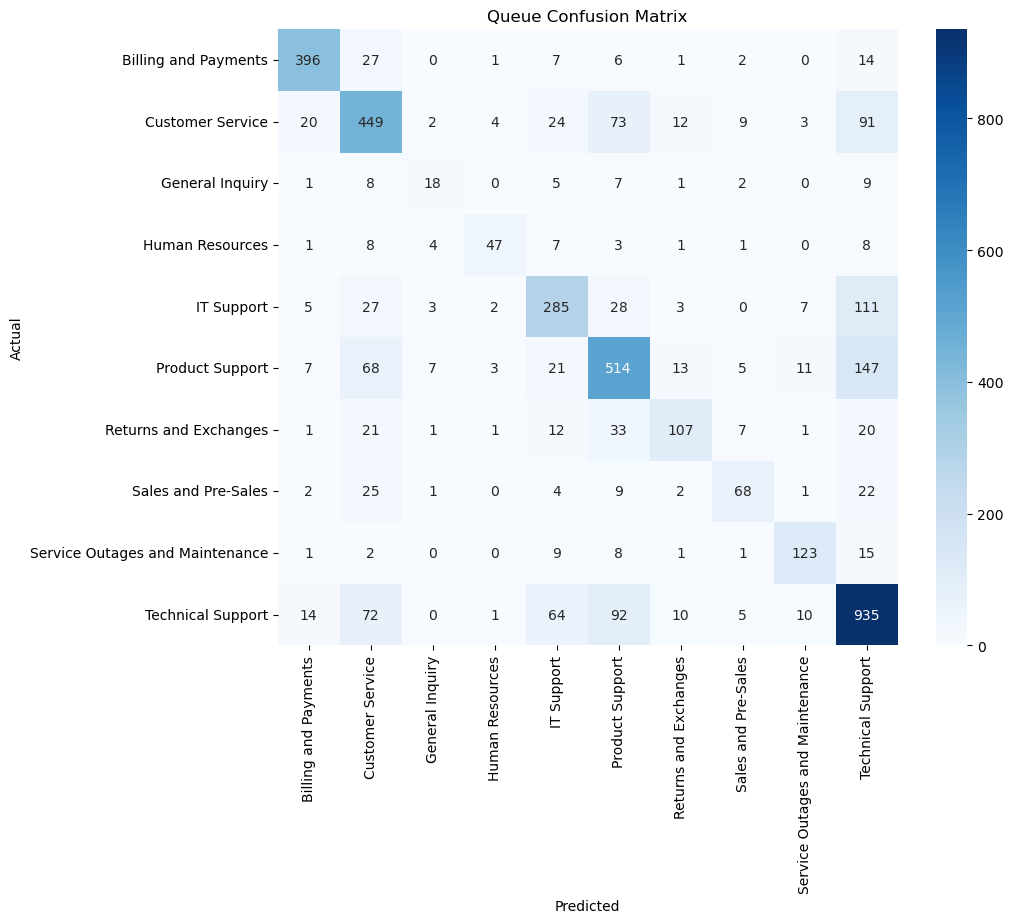

In [42]:
from sklearn.metrics import confusion_matrix
queue_cm = confusion_matrix(queue_true, queue_preds)

plt.figure(figsize=(10,8))
sns.heatmap(
    queue_cm,
    annot=True,
    fmt="d",
    xticklabels=queue_encoder.classes_,
    yticklabels=queue_encoder.classes_,
    cmap="Blues"
)
plt.title("Queue Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

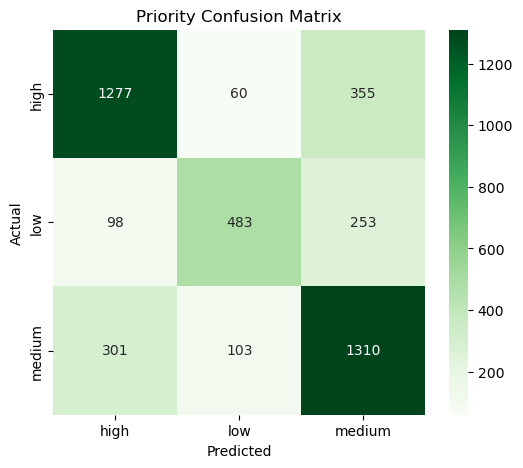

In [43]:
priority_cm = confusion_matrix(priority_true, priority_preds)

plt.figure(figsize=(6,5))
sns.heatmap(
    priority_cm,
    annot=True,
    fmt="d",
    xticklabels=priority_encoder.classes_,
    yticklabels=priority_encoder.classes_,
    cmap="Greens"
)
plt.title("Priority Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()